# Kasatria Data Scientist Assignment – Python Analysis

This notebook contains the Python-based statistical analysis for the Kasatria Data Scientist preliminary assignment.

## Analysis Covered
- Data validation and quality checks
- Age vs income analysis for Diploma holders
- Pearson correlation
- Linear regression
- R² evaluation
- Salary prediction for a 40-year-old Diploma holder
- Data visualization


## 1. Load and Inspect Dataset

In [17]:
import pandas as pd

df = pd.read_csv("kasatria_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (21, 20)


,Subject ID,Name,Age,Gender,Annual Income,Monthly Income,Education,Education Rank,Phone Owned,Brand,Is Phone?,High Earner (RM5k+/mth)?,Email,Web,Mobile,Walk-In,Video Call,Phone Call,Letter,Channels Selected
0,1.0,Ali,22.0,M,"15,000",1250.00,Highschool,2.0,Samsung Galaxy S3,Samsung,Yes,No,1.0,1.0,1.0,1.0,0.0,0.0,0.0,4.0
1,2.0,Mutu,25.0,M,"30,000",2500.00,Diploma,3.0,HTC One Note,HTC,Yes,No,1.0,1.0,1.0,0.0,0.0,0.0,0.0,3.0
2,3.0,Lim,33.0,M,"36,000",3000.00,Diploma,3.0,iPhone 5,Apple,Yes,No,1.0,1.0,1.0,0.0,1.0,0.0,0.0,4.0
3,4.0,Angie,47.0,F,"45,000",3750.00,Diploma,3.0,iPhone 6s,Apple,Yes,No,1.0,0.0,0.0,1.0,1.0,1.0,1.0,5.0
4,5.0,Jack,26.0,M,"25,000",2083.33,Degree,4.0,Xiaomi MI3,Xiaomi,Yes,No,1.0,1.0,1.0,0.0,0.0,0.0,0.0,3.0


## 2. Data Cleaning and Validation

In [18]:
# Remove completely empty rows
df = df.dropna(how="all")

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (20, 20)


In [19]:
print("Missing values by column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values by column:
Subject ID                  0
Name                        0
Age                         0
Gender                      0
Annual Income               0
Monthly Income              0
Education                   0
Education Rank              0
Phone Owned                 0
Brand                       0
Is Phone?                   0
High Earner (RM5k+/mth)?    0
Email                       0
Web                         0
Mobile                      0
Walk-In                     0
Video Call                  0
Phone Call                  0
Letter                      0
Channels Selected           0
dtype: int64

Duplicate rows: 0


## 3. Diploma Holder Dataset

In [20]:
# Filter only Diploma holders
diploma = df[df["Education"] == "Diploma"].copy()

# Convert Annual Income to numeric because the CSV contains commas
diploma["Annual Income"] = (
    diploma["Annual Income"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Show the relevant data
diploma[["Name", "Age", "Annual Income"]]

,Name,Age,Annual Income
1,Mutu,25.0,30000.0
2,Lim,33.0,36000.0
3,Angie,47.0,45000.0
11,Trevor,25.0,30000.0
12,Melinda,39.0,33000.0
13,Aishah,45.0,42000.0


## 4. Question 3 – Does Age Affect Salary for Diploma Holders?

In [21]:
# Correlation between age and annual income
correlation = diploma["Age"].corr(diploma["Annual Income"])

print("Correlation between Age and Annual Income:", round(correlation, 4))

Correlation between Age and Annual Income: 0.9132


## 5. Linear Regression Analysis

In [22]:
from sklearn.linear_model import LinearRegression

# Predictor: Age
X = diploma[["Age"]]

# Target: Annual Income
y = diploma["Annual Income"]

# Create and fit the regression model
model = LinearRegression()
model.fit(X, y)

# Regression values
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print("Slope:", round(slope, 2))
print("Intercept:", round(intercept, 2))
print("R-squared:", round(r_squared, 4))

Slope: 598.27
Intercept: 14661.85
R-squared: 0.8339


**Interpretation:**  
The model produced an **R² of 0.8339**, meaning approximately **83.4% of the variation in annual income** is explained by age within this small Diploma-holder sample. The regression slope is approximately **RM598.27 per additional year of age**.

## 6. Question 4 – Salary Prediction at Age 40

In [31]:
# Predict annual income for a 40-year-old Diploma holder
predicted_annual = model.predict(pd.DataFrame({"Age": [40]}))[0]
predicted_monthly = predicted_annual / 12

print("Predicted annual income at age 40: RM", round(predicted_annual, 2))
print("Predicted monthly income at age 40: RM", round(predicted_monthly, 2))

Predicted annual income at age 40: RM 38592.49
Predicted monthly income at age 40: RM 3216.04


**Prediction:**  
A 40-year-old Diploma holder is predicted to earn approximately **RM38,592.49 per year**, or **RM3,216.04 per month**.

## 7. Age vs Annual Income Visualization

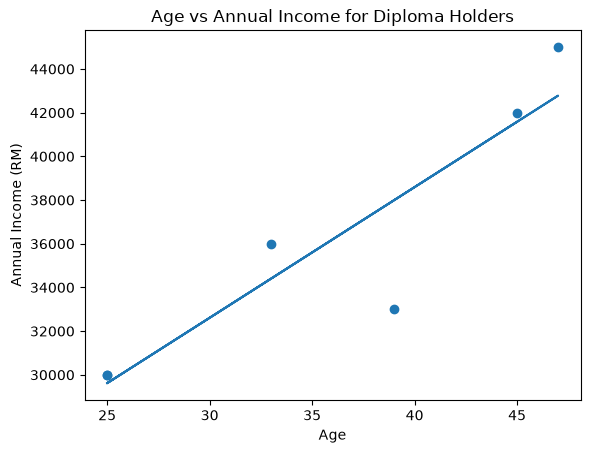

In [32]:
import matplotlib.pyplot as plt

# Scatter plot of actual Diploma-holder data
plt.scatter(diploma["Age"], diploma["Annual Income"])

# Regression line
plt.plot(diploma["Age"], model.predict(X))

plt.xlabel("Age")
plt.ylabel("Annual Income (RM)")
plt.title("Age vs Annual Income for Diploma Holders")

plt.show()

**Interpretation:**  
The scatter plot and regression line visually support the strong positive relationship between age and annual income among Diploma holders. However, the sample only contains six Diploma holders, so the result should be interpreted cautiously.

In [33]:
print("Q3 Summary")
print("Correlation:", round(correlation, 4))
print("R-squared:", round(r_squared, 4))
print("Slope:", round(slope, 2))

print("\nQ4 Summary")
print("Predicted annual income at age 40: RM", round(predicted_annual, 2))
print("Predicted monthly income at age 40: RM", round(predicted_monthly, 2))

Q3 Summary
Correlation: 0.9132
R-squared: 0.8339
Slope: 598.27

Q4 Summary
Predicted annual income at age 40: RM 38592.49
Predicted monthly income at age 40: RM 3216.04


In [34]:
# Convert Annual Income to numeric
df["Annual Income"] = (
    df["Annual Income"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print(df["Annual Income"].dtype)

float64


## 8. Average Income by Education Level

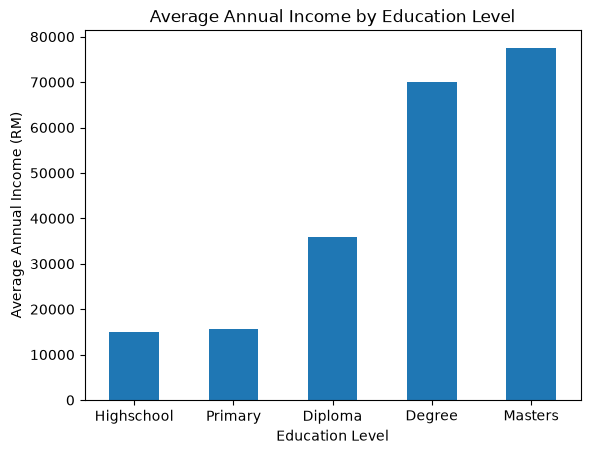

In [35]:
# Average annual income by education level

education_income = (
    df.groupby("Education")["Annual Income"]
    .mean()
    .sort_values()
)

education_income.plot(kind="bar")

plt.title("Average Annual Income by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Annual Income (RM)")
plt.xticks(rotation=0)

plt.show()

**Interpretation:**  
Average annual income differs noticeably across education levels. Masters holders have a substantially higher average income than Diploma holders in this dataset.

## 9. Phone Brand Among High Earners

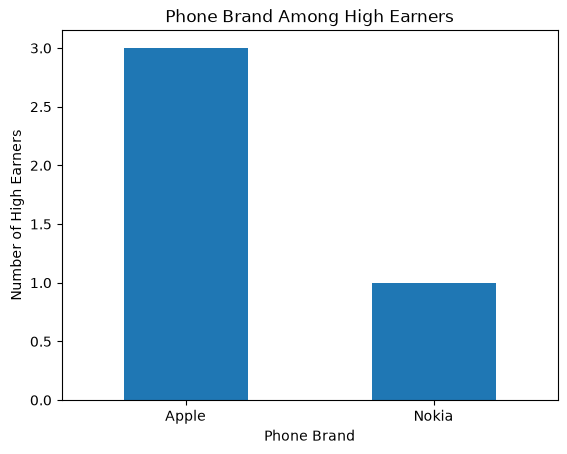

In [36]:
# Phone brand among people earning RM5,000+ per month

high_earners = df[df["Monthly Income"] >= 5000]

brand_counts = high_earners["Brand"].value_counts()

brand_counts.plot(kind="bar")

plt.title("Phone Brand Among High Earners")
plt.xlabel("Phone Brand")
plt.ylabel("Number of High Earners")
plt.xticks(rotation=0)

plt.show()

**Interpretation:**  
Among respondents earning RM5,000 or more per month, Apple is the most common phone brand, used by **3 out of 4 high earners (75%)**.

## 10. Interview Request Channel Preferences

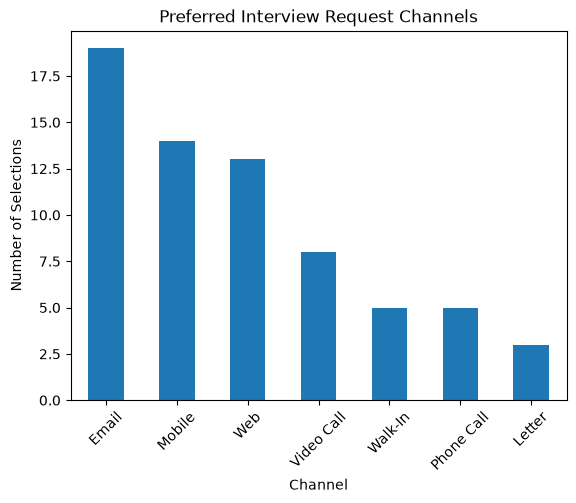

In [37]:
# Interview channel popularity

channels = [
    "Email",
    "Web",
    "Mobile",
    "Walk-In",
    "Video Call",
    "Phone Call",
    "Letter"
]

channel_counts = df[channels].sum().sort_values(ascending=False)

channel_counts.plot(kind="bar")

plt.title("Preferred Interview Request Channels")
plt.xlabel("Channel")
plt.ylabel("Number of Selections")
plt.xticks(rotation=45)

plt.show()

**Interpretation:**  
Email is the most frequently selected interview-request channel, followed by Mobile and Web. Traditional methods such as Letter and Phone Call are selected less often.